In [1]:
%load_ext autoreload
%autoreload 2 


In [2]:
import wandb
import torch.nn as nn
import torch
import numpy as np
import hydra
import einops
import os
import sys
from pathlib import Path
from dynamics_modeling.eval import batch_eval_loop
from torch.utils.data import DataLoader


os.environ["WANDB_DIR"] = '/pscratch/sd/g/gzhao27/INR/coral/wandb'
os.environ["RESULTS_DIR"] = ''

# sys.path.append(str(Path(__file__).parents[1]))
sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
sys.path.append('/pscratch/sd/g/gzhao27/INR/SOMA')
from coral.utils.plot import show
from coral.utils.models.scheduling import ode_scheduling
from coral.utils.models.load_inr import create_inr_instance, load_inr_model
from coral.utils.models.get_inr_reconstructions import get_reconstructions
from coralsoma.load_modulations import load_graph_modulations, graph_ode_inr_predict
from coral.utils.data.load_data import get_dynamics_data, set_seed
from coral.utils.data.dynamics_dataset import (KEY_TO_INDEX, TemporalDatasetWithCode)
from coral.mlp import Derivative, ParameterizedDerivative
from torchdiffeq import odeint
from omegaconf import DictConfig, OmegaConf
from utils.data.unstructure_dataset import GraphNavierStokes, collate_graph_inr, GraphSomaDataset

# with hydra.initialize(config_path="../config/"):
#     # Compose the configuration (equivalent to loading ode.yaml)
#     cfg = hydra.compose(config_name="ode.yaml")

2024-12-05 13:03:26.352255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-05 13:03:26.620314: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-05 13:03:26.713240: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-05 13:03:27.316571: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-05 13:03:31.235943: W tensorflow/compiler/tf2

## Burgers

In [ ]:
# burgers related setting
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-242024-10-14Burgers-w0_101e-05_40_ode.pt"
ode_save_path = os.path.join(inr_save_dir, ode_save_name)
ode_results = torch.load(ode_save_path)
parameterized = False
cfg = ode_results['cfg']
print(ode_results['epoch'])
print(ode_results['loss'])
input_dim = 1
output_dim = 1

z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

/tmp/ipykernel_226087/2858998350.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_results = torch.load(ode_save_path)


11780
0.04037228040397167


In [3]:
# parameterized
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-29-00-12-192024-10-14Burgers-w0_100.0001_1000_ode.pt"



ode_save_path = os.path.join(inr_save_dir, ode_save_name)
# ode_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-10-19-05-542024-10-14Burgers-w0_10burgers-no-parameter_200_1e-5_0drop_6physical_swish_ode.pt' #no parameter baseline
# parameterized = False


ode_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-09-21-08-462024-10-14Burgers-w0_10burgers-concatenate_200_1e-5_32_0drop_swish_ode.pt' # concatenation 32
parameterized = True
para_type='concatenate'
p_dim=32


ode_results = torch.load(ode_save_path)

cfg = ode_results['cfg']
print(ode_results['epoch'])
print(ode_results['loss'])
ode_results['epoch']
input_dim = 1
output_dim = 1

z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

/tmp/ipykernel_215159/319786073.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_results = torch.load(ode_save_path)


6020
0.0182313434779644


In [4]:
torch.set_default_dtype(torch.float32)
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len

missing_rate = cfg.data.missing_rate

inner_steps = cfg.inr.inner_steps

# dynamics
model_type = cfg.dynamics.model_type
hidden = cfg.dynamics.width
depth = cfg.dynamics.depth
epsilon = cfg.dynamics.teacher_forcing_init
epsilon_t = cfg.dynamics.teacher_forcing_decay
epsilon_freq = cfg.dynamics.teacher_forcing_update

if inr_save_name is not None:
    multichannel = False
    tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
    latent_dim = tmp["cfg"].inr.latent_dim
    # print('fix sub_tr to space_factor')
    space_factor = tmp["cfg"].data.space_factor
    seed = tmp["cfg"].data.seed
    # missing_rate = tmp["cfg"].data.missing_rate
    
    inr, alpha = load_inr_model(
        inr_save_dir,
        inr_save_name,
        data_to_encode,
        input_dim=input_dim,
        output_dim=output_dim,
    )

model_state_dict = ode_results['ode']
# model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
if parameterized:
    model = ParameterizedDerivative(output_dim, latent_dim, hidden, depth, para_type=para_type, p_dim=p_dim)
else:
    model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
model.load_state_dict(model_state_dict)

if 'p_mean' in ode_results:
    p_mean = ode_results['p_mean']
    p_std = ode_results['p_std']
    p_transform = lambda tensor: (tensor - p_mean) / p_std
    p_invtransform = lambda tensor: (tensor * p_std) + p_mean   
else:
    p_transform = None
    p_invtransform = None
    

/tmp/ipykernel_215159/3131530574.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
/pscratch/sd/g/gzhao2

In [5]:
# testset setting

from utils.data.unstructure_dataset import GraphBurgers

testp=0.01

test_space_factor = 1
test_time_factor = 1

X = (1024+test_space_factor-1)//test_space_factor
T = (201+test_time_factor-1)//test_time_factor

trainnum = 1000
valnum = 100
testnum = 100
startnum = trainnum+valnum
train_p_list=(0.001, 0.002, 0.004, 0.02, 0.04, 0.1)
# p_mean = np.array(train_p_list).mean()
# p_std = np.array(train_p_list).std()
# p_transform = lambda tensor: (tensor - p_mean) / p_std
# p_invtransform = lambda tensor: (tensor * p_std) + p_mean
val_p_list = (0.01, )
test_p_list = (testp, )
path_format = "/pscratch/sd/g/gzhao27/INR/data/1D_Burgers_Sols_Nu{}.hdf5"
def create_dict(p_list, start, Dnum):
    Ddict = {}
    for p in p_list:
        temppath = path_format.format(p)
        Ddict[temppath] = (list(range(start, start+Dnum)), p)
    return Ddict

traindict = create_dict(train_p_list, 0, trainnum)
valdict = create_dict(val_p_list, trainnum, valnum)
testdict = create_dict(test_p_list, trainnum+valnum, testnum)

testset = GraphBurgers(
    datapath_dict=testdict,
    latent_dim=128,
    missing_rate=0.,
    space_factor=test_space_factor,
    time_factor=test_time_factor, 
    p_transform=p_transform
)

device = torch.device('cpu')
alpha = alpha.to(device)
model.to(device)
inr.to(device)

data_path = f"/pscratch/sd/g/gzhao27/INR/SOMA/results/testset_{inr_save_name}_p{testp}_start{startnum}_factor{test_space_factor}.pth"
if os.path.exists(data_path):
    modulation_tensor = torch.load(data_path)
    assert len(modulation_tensor) == len(testset)
    for i, graph in enumerate(testset):
        graph.latent_vector = modulation_tensor[i]
else:
    load_graph_modulations(
        testset,
        inr,
        device=device,
        inner_steps=inner_steps,
        alpha=alpha,
        batch_size=2,
    )
    temp_list = []
    for graph in testset:
        temp_list.append(graph.latent_vector)
    modulation_tensor = torch.stack(temp_list)
    torch.save(modulation_tensor, data_path)
    

/tmp/ipykernel_215159/2578552036.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modulation_tensor = torch.load(data_path)


In [ ]:
sys.path.append('/pscratch/sd/g/gzhao27/INR/SOMA/coralsoma')
from train import modulation_fix, ode_pred_z

batch_size = 20
test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_graph_inr,
    num_workers=1,
)

T_test = testset[0].T
ntest = len(testset)
dt=1
timestamps_test = torch.arange(0, T_test, dt).float().to(device)
timestamps_test /= (time_factor/test_time_factor)
timestamps_test /= 10
image_test_mse = 0
z_test_mse = 0
inr_test_mse = 0


for substep, graph in enumerate(test_loader): 
    
    model.eval()
    n_samples = len(graph)
    modulations = graph.latent_vector

    modulations = modulation_fix(modulations, n_samples, T_test, latent_dim, z_transform)
    modulations = modulations.to(device)
    graph = graph.to(device)
    z_pred = ode_pred_z(model, graph, modulations, timestamps_test, 0, parameterized)
    loss = ((z_pred - modulations) ** 2).mean()
    z_test_mse  += loss.item()*n_samples

    outputs = graph_ode_inr_predict(
        model, 
        inr, 
        graph, 
        timestamps=timestamps_test,
        device=device,
        z_transform=z_transform,
        z_invtransform=z_invtransform, 
        parameterized=parameterized,
        )
    image_pred_loss = outputs['ode_pred_loss']
    image_test_mse += image_pred_loss * n_samples
    inr_pred_loss = outputs['inr_pred_loss']
    inr_test_mse += inr_pred_loss*n_samples

ode_pred = outputs['ode_pred']
inr_pred = outputs['inr_pred']

inr_test_mse = inr_test_mse/ntest
image_test_mse = image_test_mse/ntest
z_test_mse = z_test_mse/ntest
print("val latent loss:", z_test_mse)
print("val image loss:", image_test_mse)
print('inr mse:', inr_test_mse)

/pscratch/sd/g/gzhao27/INR/SOMA/coralsoma/train.py:79: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../config/", config_name="ode.yaml")


val latent loss: 0.04801703691482544
val image loss: tensor(0.0158, grad_fn=<DivBackward0>)
inr mse: tensor(0.0005, grad_fn=<DivBackward0>)


In [ ]:
inr_test_mse.item()

0.0004647820023819804

In [ ]:
outputs

{'ode_pred': tensor([[-0.9681],
         [-0.9254],
         [-0.8641],
         ...,
         [-0.1046],
         [-0.1042],
         [-0.1021]]),
 'ode_pred_loss': tensor(0.0107, grad_fn=<MeanBackward0>),
 'inr_pred': tensor([[-0.9681],
         [-0.9254],
         [-0.8641],
         ...,
         [-0.0952],
         [-0.0948],
         [-0.0931]]),
 'inr_pred_loss': tensor(0.0004, grad_fn=<MeanBackward0>),
 'z_pred_loss': tensor(0.0308, grad_fn=<MeanBackward0>)}

Text(0.5, 1.0, 'CORAL Prediction')

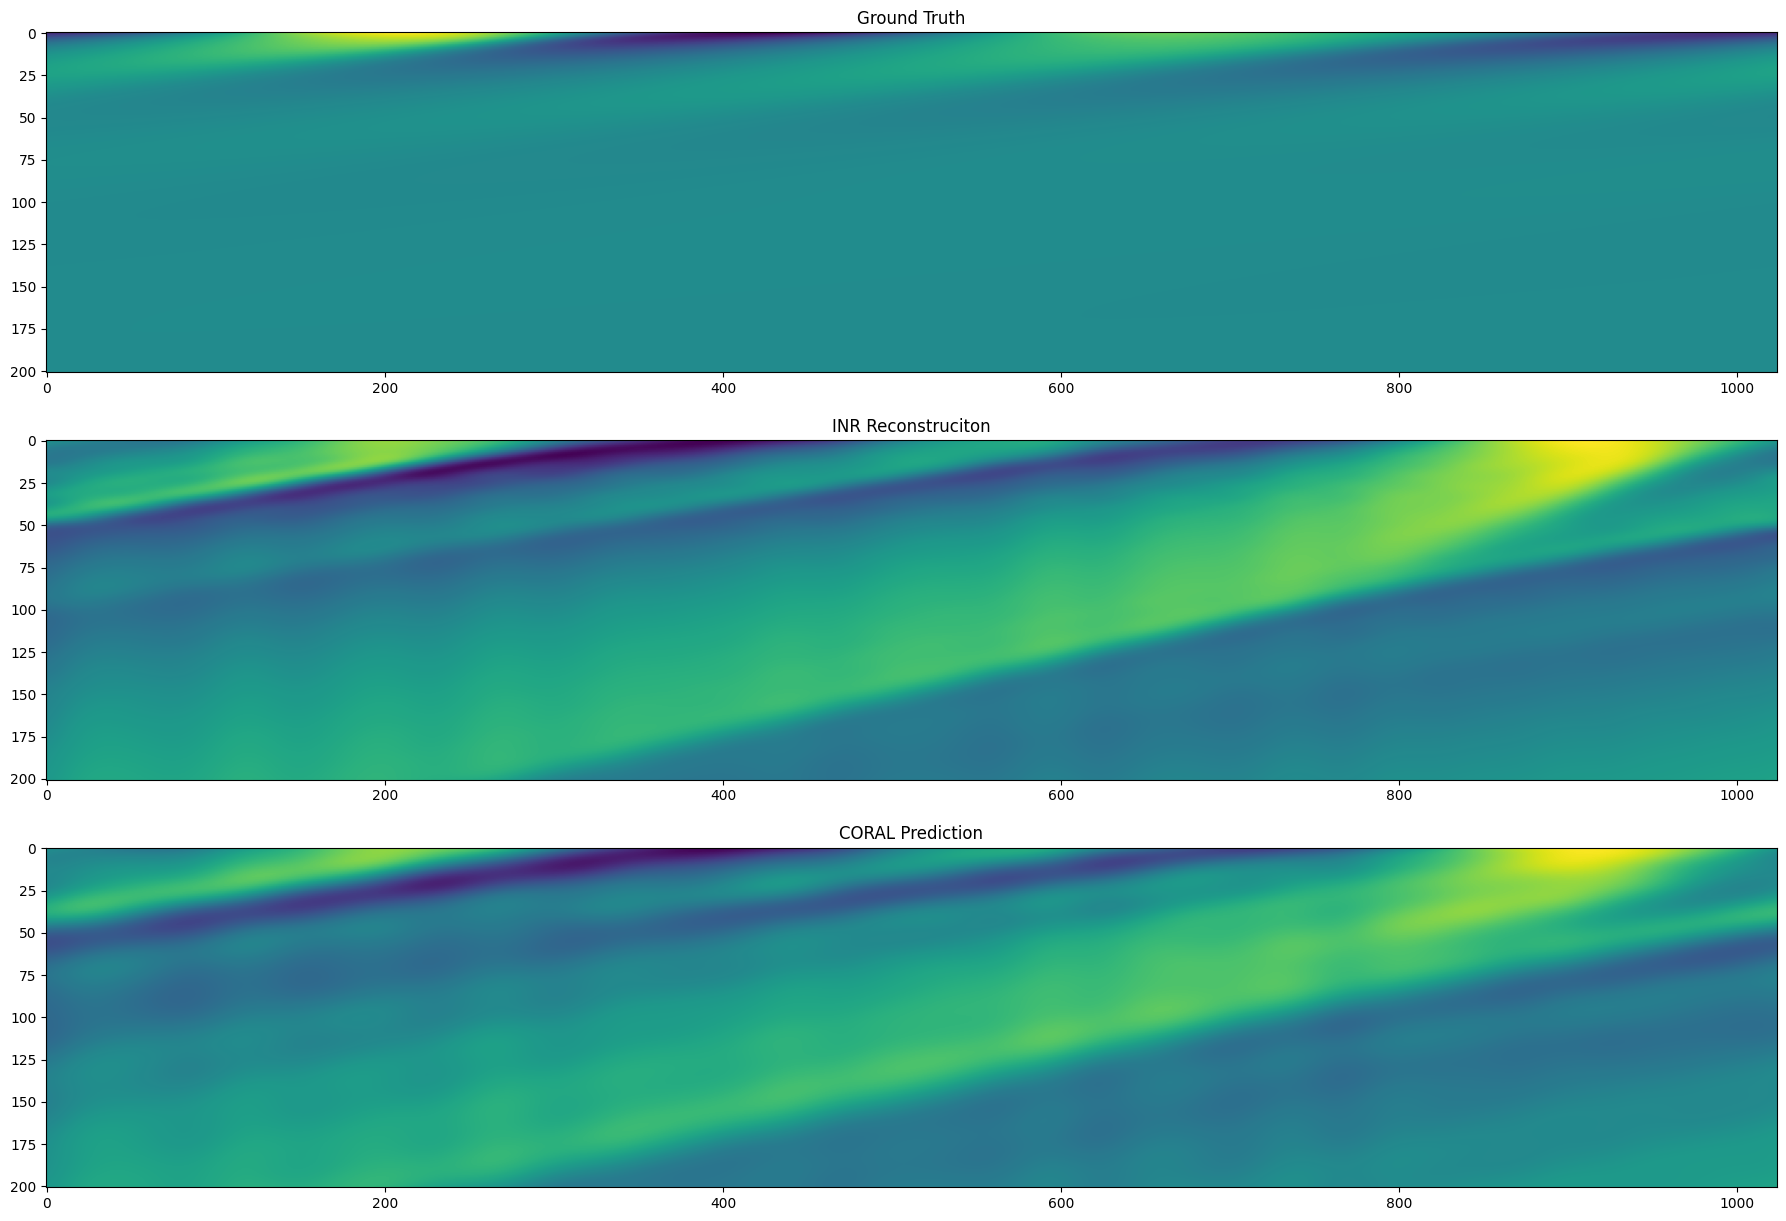

In [ ]:
import matplotlib.pyplot as plt


showidx = 1


ode_pred = ode_pred.reshape(-1, T, X) 
inr_pred = inr_pred.reshape(-1, T, X) 
image_ori = graph[showidx].feat.reshape(T, X).cpu()

fig, axes = plt.subplots(3, 1, figsize=(30, 15))

# Set the overall title for the figure
# fig.suptitle("Superresolution")

axes[0].imshow(image_ori)
axes[0].set_title("Ground Truth")

axes[1].imshow(inr_pred[showidx])
axes[1].set_title("INR Reconstruciton")

axes[2].imshow(ode_pred[showidx])
axes[2].set_title("CORAL Prediction")


# plt.figure(figsize=(30, 10))
# plt.imshow(image_ori)
# plt.figure(figsize=(30, 10))
# plt.imshow(inr_pred[showidx])
# plt.figure(figsize=(30, 10))
# plt.imshow(ode_pred[showidx])

In [ ]:
p_list = (0.001, 0.002, 0.004, 0.01, 0.02, 0.04, 0.1)
testnum=2
true_list = []
pred_list = []
for i, p in enumerate(p_list):
    test_p_list = (p, )
    testdict = create_dict(test_p_list, trainnum+valnum, testnum)
    testset = GraphBurgers(
        datapath_dict=testdict,
        latent_dim=128,
        missing_rate=0.,
        space_factor=test_space_factor,
        time_factor=test_time_factor, 
        p_transform=p_transform,
    )
    device = torch.device('cpu')
    alpha = alpha.to(device)
    model.to(device)
    inr.to(device)
    load_graph_modulations(
        testset,
        inr,
        device=device,
        inner_steps=inner_steps,
        alpha=alpha,
        batch_size=testnum,
    )
    test_loader = DataLoader(
        testset,
        batch_size=testnum,
        shuffle=False,
        collate_fn=collate_graph_inr,
        num_workers=1,
    )
    graph = next(iter(test_loader))
    modulations = graph.latent_vector
    modulations = modulation_fix(modulations, testnum, T_test, latent_dim, z_transform, device=device)
    modulations = modulations.to(device)
    graph = graph.to(device)
    z_pred = ode_pred_z(model, graph, modulations, timestamps_test, 0, parameterized)
    pred_list.append(z_pred)
    true_list.append(modulations)

# plt.plot(p_list, true_list, 'o-')
# plt.ylabel('Latent Space Distance at Consecutive Time Steps')
# plt.xlabel('parameters')
# print(torch.norm(start))

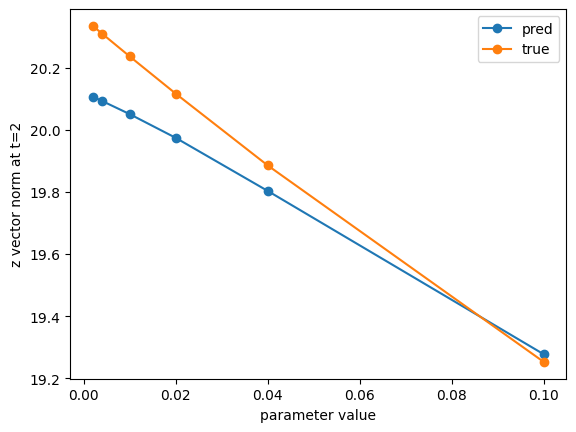

In [ ]:
idx=1
tidx =2
pred_1 = []
true_1 = []
for i in range(1, 7):
    pred_1.append(torch.norm(pred_list[i][idx][:, tidx] ).detach().numpy())
    true_1.append(torch.norm(true_list[i][idx][:, tidx]).detach().numpy())
plt.plot(p_list[1:], pred_1, 'o-', label='pred')
plt.plot(p_list[1:], true_1, 'o-', label='true')
plt.xlabel('parameter value')
plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()


In [ ]:
len(pred_list[0])

2

In [ ]:
batch_size

20

In [ ]:
pred_t[1]

array([5.0193553 , 2.709744  , 0.6991549 , 2.5040557 , 0.895856  ,
       1.9373335 , 1.6950253 , 1.3133973 , 1.1179638 , 2.4667873 ,
       3.355335  , 1.3145714 , 0.5284819 , 1.3464835 , 3.7312875 ,
       5.6292815 , 0.96308404, 0.39685765, 0.47741005, 3.0949805 ,
       1.1991954 , 1.5352966 , 0.86613566, 3.2012355 , 2.6299858 ,
       1.0648719 , 1.3701767 , 1.7301937 , 0.7850204 , 0.43755096,
       0.83815444, 3.712051  , 1.0223166 , 8.848246  , 0.91633886,
       2.4394286 , 1.962287  , 0.9711667 , 2.7050984 , 1.2816741 ,
       2.7052696 , 3.4181728 , 1.6555419 , 0.52761257, 4.3278866 ,
       1.6357278 , 3.211708  , 1.3601213 , 5.150215  , 1.1867833 ,
       1.5393152 , 2.8893297 , 0.4155941 , 0.7700022 , 3.3310864 ,
       0.41443712, 2.216179  , 1.5566375 , 2.5666678 , 2.5500135 ,
       1.0035452 , 0.86154604, 1.616029  , 3.2135892 , 1.0269322 ,
       3.2976365 , 1.9718251 , 1.1060067 , 0.3724461 , 1.4553298 ,
       1.8840007 , 1.3522689 , 0.6748426 , 1.4213481 , 2.64770

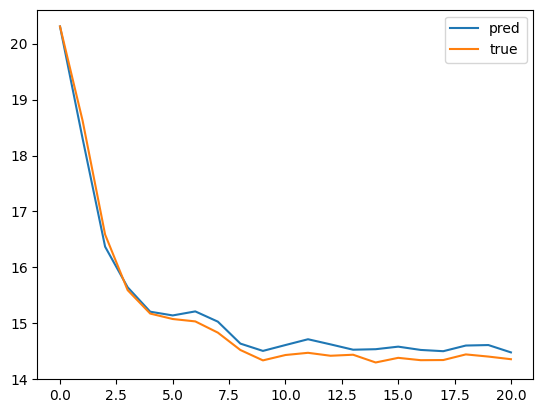

In [ ]:
pred_t = []
true_t = []
for t in range(0, T):
    pred_t.append(torch.norm(pred_list[1][idx][:, t] ).detach().numpy())
    true_t.append(torch.norm(true_list[1][idx][:, t] ).detach().numpy())
plt.plot(pred_t, label='pred')
plt.plot(true_t, label='true')
# plt.xlabel('parameter value')
# plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()

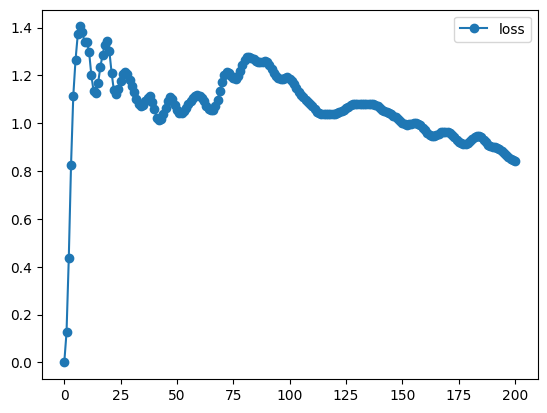

In [ ]:
pred_t = [0]*T
true_t = [0]*T
for t in range(0, T):
    for pid in range(0, len(p_list)):
        for idx in range(2):
            pred_t[t] += ((pred_list[pid][idx][:, t] - true_list[pid][idx][:, t])**2).detach().numpy().mean()
            # pred_t.append(torch.norm(pred_list[1][idx][:, t] ).detach().numpy())
            # true_t.append(torch.norm(true_list[1][idx][:, t] ).detach().numpy())
plt.plot(pred_t, '-o', label='loss',)
# plt.plot(true_t, label='true')
# plt.xlabel('parameter value')
# plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()

# NS task

In [1]:
# NS task

input_dim = 1
output_dim = 2

# inr
inr_save_name = "NS_test_show"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "NS_test_ode_show"

ode_save_path = os.path.join(inr_save_dir, ode_save_name+'.pt')
ode_results = torch.load(ode_save_path)

cfg = ode_results['cfg']



NameError: name 'os' is not defined

In [4]:


torch.set_default_dtype(torch.float32)
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len

missing_rate = cfg.data.missing_rate

inner_steps = cfg.inr.inner_steps

# dynamics
model_type = cfg.dynamics.model_type
hidden = cfg.dynamics.width
depth = cfg.dynamics.depth
epsilon = cfg.dynamics.teacher_forcing_init
epsilon_t = cfg.dynamics.teacher_forcing_decay
epsilon_freq = cfg.dynamics.teacher_forcing_update



In [5]:
input_dim = 2
output_dim = 1


if inr_save_name is not None:
    multichannel = False
    tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
    latent_dim = tmp["cfg"].inr.latent_dim
    # print('fix sub_tr to space_factor')
    space_factor = tmp["cfg"].data.space_factor
    seed = tmp["cfg"].data.seed
    # missing_rate = tmp["cfg"].data.missing_rate
    
    inr, alpha = load_inr_model(
        inr_save_dir,
        inr_save_name,
        data_to_encode,
        input_dim=input_dim,
        output_dim=output_dim,
    )

/tmp/ipykernel_1247122/2577899674.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
/pscratch/sd/g/gzhao2

In [17]:
inr

ModulatedSiren(
  (net): Sequential(
    (0): SirenLayer(
      (linear): Linear(in_features=3, out_features=32, bias=True)
      (activation): Sine()
    )
    (1): SirenLayer(
      (linear): Linear(in_features=32, out_features=32, bias=True)
      (activation): Sine()
    )
  )
  (last_layer): SirenLayer(
    (linear): Linear(in_features=32, out_features=1, bias=True)
    (activation): Sine()
  )
  (last_activation): Identity()
  (modulation_net): LatentToModulation(
    (net): Linear(in_features=128, out_features=64, bias=True)
  )
)

In [14]:
z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

In [6]:
model_state_dict = ode_results['ode']
model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [24]:
testset = GraphNavierStokes(split='test', datanum=20, missing_rate=0.0, latent_dim=latent_dim)
load_graph_modulations(
    testset,
    inr,
    inner_steps=inner_steps,
    alpha=alpha,
    batch_size=2,
)

(-0.0003125140501651913, 0.008481579832732677)

In [27]:
test_loader = DataLoader(
    testset,
    batch_size=20,
    shuffle=True,
    collate_fn=collate_graph_inr,
    num_workers=1,
)

In [28]:
graph = next(iter(test_loader))
outputs = graph_ode_inr_predict(
    
    model, 
    inr, 
    graph, 
    timestamps=None,
    z_transform=z_transform,
    z_invtransform=z_invtransform
    )
ode_pred = outputs['ode_pred']
inr_pred = outputs['inr_pred']

In [29]:
outputs

{'ode_pred': tensor([[-0.2237],
         [-0.1840],
         [-0.1563],
         ...,
         [ 0.4024],
         [ 0.6231],
         [ 0.8365]]),
 'ode_pred_loss': tensor(0.0147, device='cuda:0', grad_fn=<MeanBackward0>),
 'inr_pred': tensor([[-0.2237],
         [-0.1840],
         [-0.1563],
         ...,
         [ 0.3285],
         [ 0.5535],
         [ 0.7660]]),
 'inr_pred_loss': tensor(0.0044, device='cuda:0', grad_fn=<MeanBackward0>),
 'z_pred_loss': tensor(0.0314, device='cuda:0', grad_fn=<MeanBackward0>)}

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Assume coordinates and values are given as tensors
# coordinates: (64**2, 2), values: (64**2, 1)
dimage = testset.height

def graph2image(graph, image_pred):
    T = graph.T.sum()
    video_gt = np.zeros((T, dimage, dimage))
    video_pred = np.zeros((T, dimage, dimage))
    
    
    for t in range(T):
        tidx = graph.time ==t
        coordinates = graph.cor[tidx]
        values_gt = graph.feat[tidx]
        values_pred = image_pred[tidx]
        
        coordinates_np = coordinates.numpy()
        values_gt = values_gt.numpy().reshape(-1)
        values_pred = values_pred.numpy().reshape(-1)
        
        for i, (x, y) in enumerate(coordinates_np):
            video_gt[t, x, y] = values_gt[i]
            video_pred[t, x, y] = values_pred[i]
    
    return video_gt, video_pred

def drawimage(graph, value_pred, t, test=False):

    tidx = graph.time ==t
    coordinates = graph.cor[tidx]
    if not test:
        values = graph.feat[tidx]
    else:
        values = value_pred[tidx]

    # Convert tensors to numpy arrays
    coordinates_np = coordinates.numpy()
    values_np = values.numpy().reshape(-1)

    # Create an empty 2D array to hold the pixel values
    image = np.zeros((dimage, dimage))

    # Populate the image using the coordinates and values
    for i, (x, y) in enumerate(coordinates_np):
        image[x, y] = values_np[i]

    # Plot the image using matplotlib
    plt.imshow(image,)  # You can change 'gray' to another colormap if desired
    plt.colorbar()  # Optional: Adds a colorbar to show value scale
    plt.title("64x64 Image from Coordinates and Values")
    plt.show()

In [31]:
video_gt, video_pred = graph2image(graph, ode_pred)
_, video_inr = graph2image(graph, inr_pred)

In [33]:
video_gt.shape

(1000, 64, 64)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML

# Assuming your tensor is a 3D numpy array of shape (50, 64, 64)
tensor1 = video_gt  # Replace this with your actual tensor
tensor2 = video_inr
tensor3 = video_pred

# Create a figure and axis to display the images
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

# Display the first frame
im1 = ax1.imshow(tensor1[0], vmax = 1.5, vmin = -1.5)
im2 = ax2.imshow(tensor2[0], vmax = 1.5, vmin = -1.5)
im3 = ax3.imshow(tensor3[0], vmax = 1.5, vmin = -1.5)

ax1.set_title('Ground Truth')
ax2.set_title('INR prediction')
ax3.set_title('ODE prediction')

# Update function for animation
def update(frame):
    im1.set_array(tensor1[frame])
    im2.set_array(tensor2[frame])
    im3.set_array(tensor2[frame])
    return [im1, im2, im3]

# Create an animation
ani = FuncAnimation(fig, update, frames=range(tensor1.shape[0]), blit=True, interval=100)

# Use HTML to display the animation in the notebook
HTML(ani.to_jshtml())




# SOMA task

In [ ]:

# inr
inr_save_name = "2024-10-07SOMA-w0_30"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-202024-10-07SOMA-w0_30_ode.pt"
ode_save_path = os.path.join(inr_save_dir, ode_save_name)
ode_results = torch.load(ode_save_path)

cfg = ode_results['cfg']
ode_results['epoch']

In [5]:


torch.set_default_dtype(torch.float32)
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len

missing_rate = cfg.data.missing_rate

inner_steps = cfg.inr.inner_steps

# dynamics
model_type = cfg.dynamics.model_type
hidden = cfg.dynamics.width
depth = cfg.dynamics.depth
epsilon = cfg.dynamics.teacher_forcing_init
epsilon_t = cfg.dynamics.teacher_forcing_decay
epsilon_freq = cfg.dynamics.teacher_forcing_update



In [6]:
input_dim = 3
output_dim = 1


if inr_save_name is not None:
    multichannel = False
    tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
    latent_dim = tmp["cfg"].inr.latent_dim
    # print('fix sub_tr to space_factor')
    space_factor = tmp["cfg"].data.space_factor
    seed = tmp["cfg"].data.seed
    # missing_rate = tmp["cfg"].data.missing_rate
    
    inr, alpha = load_inr_model(
        inr_save_dir,
        inr_save_name,
        data_to_encode,
        input_dim=input_dim,
        output_dim=output_dim,
    )

/tmp/ipykernel_1563671/827421945.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
/pscratch/sd/g/gzhao27

In [7]:
z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

In [8]:
model_state_dict = ode_results['ode']
model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [18]:
testset = GraphSomaDataset(
            data_path='/global/cfs/cdirs/m4259/ecucuzzella/soma_ppe_data/ml_converted/month_1/thedataset-impliciBottomDrag.hdf5',
            train_num=10, 
            feature_set=[10],
            reduced_resolution=4,
            reduced_resolution_t=2, 
            latent_dim=latent_dim,
            split='test'
        )
load_graph_modulations(
    testset,
    inr,
    inner_steps=inner_steps,
    alpha=alpha,
    batch_size=2,
)

(-3.7310626794351265e-05, 0.000739774783141911)

In [35]:
test_loader = DataLoader(
    testset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_graph_inr,
    num_workers=1,
)

In [36]:
sys.path.append('/pscratch/sd/g/gzhao27/INR/SOMA/coralsoma')
graph = next(iter(test_loader))
outputs = graph_ode_inr_predict(
    model, 
    inr, 
    graph, 
    timestamps=None
    z_transform=z_transform,
    z_invtransform=z_invtransform
    )
ode_pred = outputs['ode_pred']
inr_pred = outputs['inr_pred']

In [39]:
outputs

{'ode_pred': tensor([[ 0.5538],
         [ 0.7394],
         [ 0.8790],
         ...,
         [-1.2619],
         [-1.2118],
         [-1.1439]]),
 'ode_pred_loss': tensor(0.0106, device='cuda:0', grad_fn=<MeanBackward0>),
 'inr_pred': tensor([[ 0.5538],
         [ 0.7394],
         [ 0.8790],
         ...,
         [-1.2619],
         [-1.2118],
         [-1.1439]]),
 'inr_pred_loss': tensor(0.0106, device='cuda:0', grad_fn=<MeanBackward0>),
 'z_pred_loss': tensor(0., device='cuda:0', grad_fn=<MeanBackward0>)}

In [56]:
graph[1].cor.max(dim=0).values+1

tensor([15, 25, 25])

In [64]:
image_pred = ode_pred
t = 0
T = graph.T.sum()
video_gt = np.zeros((T, X, Y))
video_pred = np.zeros((T, X, Y))

tidx = graph.time ==t
coordinates = graph.cor[tidx]
values_gt = graph.feat[tidx]
values_pred = image_pred[tidx]
zidx = coordinates[:, 0] == Z
coordinates = coordinates[zidx]
values_gt = values_gt[zidx]
values_pred = values_pred[zidx]

# coordinates_np = coordinates.numpy()
# values_gt = values_gt.numpy().reshape(-1)
# values_pred = values_pred.numpy().reshape(-1)

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Assume coordinates and values are given as tensors
# coordinates: (64**2, 2), values: (64**2, 1)
Z, X, Y= graph[1].cor.max(dim=0).values+1
Z = 0

def graph2image(graph, image_pred):
    T = graph.T.sum()
    video_gt = np.zeros((T, X, Y))
    video_pred = np.zeros((T, X, Y))
    
    
    for t in range(T):
        tidx = graph.time ==t
        coordinates = graph.cor[tidx]
        values_gt = graph.feat[tidx]
        values_pred = image_pred[tidx]
        zidx = coordinates[:, 0] == Z
        coordinates = coordinates[zidx]
        values_gt = values_gt[zidx]
        values_pred = values_pred[zidx]
        
        coordinates_np = coordinates.numpy()
        values_gt = values_gt.numpy().reshape(-1)
        values_pred = values_pred.numpy().reshape(-1)
        
        for i, (z, x, y) in enumerate(coordinates_np):
            video_gt[t, x, y] = values_gt[i]
            video_pred[t, x, y] = values_pred[i]
    
    return video_gt, video_pred

In [70]:
video_gt, video_pred = graph2image(graph, ode_pred)
_, video_inr = graph2image(graph, inr_pred)

In [ ]:
video_gt.shape

(1000, 64, 64)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML

# Assuming your tensor is a 3D numpy array of shape (50, 64, 64)
tensor1 = video_gt  # Replace this with your actual tensor
tensor2 = video_inr
tensor3 = video_pred

# Create a figure and axis to display the images
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

# Display the first frame
im1 = ax1.imshow(tensor1[0], vmax = 1.5, vmin = -1.5)
im2 = ax2.imshow(tensor2[0], vmax = 1.5, vmin = -1.5)
im3 = ax3.imshow(tensor3[0], vmax = 1.5, vmin = -1.5)

ax1.set_title('Ground Truth')
ax2.set_title('INR prediction')
ax3.set_title('ODE prediction')

# Update function for animation
def update(frame):
    im1.set_array(tensor1[frame])
    im2.set_array(tensor2[frame])
    im3.set_array(tensor2[frame])
    return [im1, im2, im3]

# Create an animation
ani = FuncAnimation(fig, update, frames=range(tensor1.shape[0]), blit=True, interval=100)

# Use HTML to display the animation in the notebook
HTML(ani.to_jshtml())




# Burgers

In [3]:
# burgers related setting
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-242024-10-14Burgers-w0_101e-05_40_ode.pt"
ode_save_path = os.path.join(inr_save_dir, ode_save_name)
ode_results = torch.load(ode_save_path)
parameterized = False
cfg = ode_results['cfg']
print(ode_results['epoch'])
print(ode_results['loss'])
input_dim = 1
output_dim = 1

z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

/tmp/ipykernel_226087/2858998350.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_results = torch.load(ode_save_path)


11780
0.04037228040397167


In [216]:
# burgers related setting
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-242024-10-14Burgers-w0_101e-05_40_ode.pt"
ode_save_path = os.path.join(inr_save_dir, ode_save_name)
ode_save_path = "/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-05-16-40-522024-10-14Burgers-w0_10burgers-no-parameter_1000_1e-5_6physical_ode.pt"
ode_results = torch.load(ode_save_path)
parameterized = False
cfg = ode_results['cfg']
print(ode_results['epoch'])
print(ode_results['loss'])
input_dim = 1
output_dim = 1

z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

1180
0.02005441177636385


/tmp/ipykernel_681494/1563287352.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_results = torch.load(ode_save_path)


In [4]:
# parameterized
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/results"
ode_save_name = "2024-10-29-00-12-192024-10-14Burgers-w0_100.0001_1000_ode.pt"



ode_save_path = os.path.join(inr_save_dir, ode_save_name)
# ode_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-10-19-05-542024-10-14Burgers-w0_10burgers-no-parameter_200_1e-5_0drop_6physical_swish_ode.pt'
# parameterized = False


ode_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-09-21-08-462024-10-14Burgers-w0_10burgers-concatenate_200_1e-5_32_0drop_swish_ode.pt'
parameterized = True
para_type='concatenate'
p_dim=32


ode_results = torch.load(ode_save_path)

cfg = ode_results['cfg']
print(ode_results['epoch'])
print(ode_results['loss'])
ode_results['epoch']
input_dim = 1
output_dim = 1

z_mean = ode_results['z_mean']
z_std = ode_results['z_std']
z_transform = lambda tensor: (tensor - z_mean) / z_std
z_invtransform = lambda tensor: (tensor * z_std) + z_mean

6020
0.0182313434779644


/tmp/ipykernel_226087/1200403225.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ode_results = torch.load(ode_save_path)


In [5]:
torch.set_default_dtype(torch.float32)
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len

missing_rate = cfg.data.missing_rate

inner_steps = cfg.inr.inner_steps

# dynamics
model_type = cfg.dynamics.model_type
hidden = cfg.dynamics.width
depth = cfg.dynamics.depth
epsilon = cfg.dynamics.teacher_forcing_init
epsilon_t = cfg.dynamics.teacher_forcing_decay
epsilon_freq = cfg.dynamics.teacher_forcing_update

if inr_save_name is not None:
    multichannel = False
    tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
    latent_dim = tmp["cfg"].inr.latent_dim
    # print('fix sub_tr to space_factor')
    space_factor = tmp["cfg"].data.space_factor
    seed = tmp["cfg"].data.seed
    # missing_rate = tmp["cfg"].data.missing_rate
    
    inr, alpha = load_inr_model(
        inr_save_dir,
        inr_save_name,
        data_to_encode,
        input_dim=input_dim,
        output_dim=output_dim,
    )

model_state_dict = ode_results['ode']
# model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
if parameterized:
    model = ParameterizedDerivative(output_dim, latent_dim, hidden, depth, para_type=para_type, p_dim=p_dim)
else:
    model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
model.load_state_dict(model_state_dict)

if 'p_mean' in ode_results:
    p_mean = ode_results['p_mean']
    p_std = ode_results['p_std']
    p_transform = lambda tensor: (tensor - p_mean) / p_std
    p_invtransform = lambda tensor: (tensor * p_std) + p_mean   
else:
    p_transform = None
    p_invtransform = None
    

/tmp/ipykernel_226087/3131530574.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tmp = torch.load(os.path.join(inr_save_dir, inr_save_name+'.pt'))
/pscratch/sd/g/gzhao2

In [6]:
# testset setting

from utils.data.unstructure_dataset import GraphBurgers

testp=0.01

test_space_factor = 1
test_time_factor = 1

X = (1024+test_space_factor-1)//test_space_factor
T = (201+test_time_factor-1)//test_time_factor

trainnum = 1000
valnum = 100
testnum = 100
startnum = trainnum+valnum
train_p_list=(0.001, 0.002, 0.004, 0.02, 0.04, 0.1)
# p_mean = np.array(train_p_list).mean()
# p_std = np.array(train_p_list).std()
# p_transform = lambda tensor: (tensor - p_mean) / p_std
# p_invtransform = lambda tensor: (tensor * p_std) + p_mean
val_p_list = (0.01, )
test_p_list = (testp, )
path_format = "/pscratch/sd/g/gzhao27/INR/data/1D_Burgers_Sols_Nu{}.hdf5"
def create_dict(p_list, start, Dnum):
    Ddict = {}
    for p in p_list:
        temppath = path_format.format(p)
        Ddict[temppath] = (list(range(start, start+Dnum)), p)
    return Ddict

traindict = create_dict(train_p_list, 0, trainnum)
valdict = create_dict(val_p_list, trainnum, valnum)
testdict = create_dict(test_p_list, trainnum+valnum, testnum)

testset = GraphBurgers(
    datapath_dict=testdict,
    latent_dim=128,
    missing_rate=0.,
    space_factor=test_space_factor,
    time_factor=test_time_factor, 
    p_transform=p_transform
)

device = torch.device('cpu')
alpha = alpha.to(device)
model.to(device)
inr.to(device)

data_path = f"/pscratch/sd/g/gzhao27/INR/SOMA/results/testset_{inr_save_name}_p{testp}_start{startnum}_factor{test_space_factor}.pth"
if os.path.exists(data_path):
    modulation_tensor = torch.load(data_path)
    assert len(modulation_tensor) == len(testset)
    for i, graph in enumerate(testset):
        graph.latent_vector = modulation_tensor[i]
else:
    load_graph_modulations(
        testset,
        inr,
        device=device,
        inner_steps=inner_steps,
        alpha=alpha,
        batch_size=2,
    )
    temp_list = []
    for graph in testset:
        temp_list.append(graph.latent_vector)
    modulation_tensor = torch.stack(temp_list)
    torch.save(modulation_tensor, data_path)
    

/tmp/ipykernel_226087/2578552036.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modulation_tensor = torch.load(data_path)


In [7]:
sys.path.append('/pscratch/sd/g/gzhao27/INR/SOMA/coralsoma')
from train import modulation_fix, ode_pred_z

batch_size = 20
test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_graph_inr,
    num_workers=1,
)

T_test = testset[0].T
ntest = len(testset)
dt=1
timestamps_test = torch.arange(0, T_test, dt).float().to(device)
timestamps_test /= (time_factor/test_time_factor)
timestamps_test /= 10
image_test_mse = 0
z_test_mse = 0
inr_test_mse = 0


for substep, graph in enumerate(test_loader): 
    
    model.eval()
    n_samples = len(graph)
    modulations = graph.latent_vector

    modulations = modulation_fix(modulations, n_samples, T_test, latent_dim, z_transform)
    modulations = modulations.to(device)
    graph = graph.to(device)
    z_pred = ode_pred_z(model, graph, modulations, timestamps_test, 0, parameterized)
    loss = ((z_pred - modulations) ** 2).mean()
    z_test_mse  += loss.item()*n_samples

    outputs = graph_ode_inr_predict(
        model, 
        inr, 
        graph, 
        timestamps=timestamps_test,
        device=device,
        z_transform=z_transform,
        z_invtransform=z_invtransform, 
        parameterized=parameterized,
        )
    image_pred_loss = outputs['ode_pred_loss']
    image_test_mse += image_pred_loss * n_samples
    inr_pred_loss = outputs['inr_pred_loss']
    inr_test_mse += inr_pred_loss*n_samples

ode_pred = outputs['ode_pred']
inr_pred = outputs['inr_pred']

inr_test_mse = inr_test_mse/ntest
image_test_mse = image_test_mse/ntest
z_test_mse = z_test_mse/ntest
print("val latent loss:", z_test_mse)
print("val image loss:", image_test_mse)
print('inr mse:', inr_test_mse)

/pscratch/sd/g/gzhao27/INR/SOMA/coralsoma/train.py:79: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../config/", config_name="ode.yaml")


val latent loss: 0.04801703691482544
val image loss: tensor(0.0158, grad_fn=<DivBackward0>)
inr mse: tensor(0.0005, grad_fn=<DivBackward0>)


In [8]:
inr_test_mse.item()

0.0004647820023819804

In [66]:
outputs

{'ode_pred': tensor([[-0.9681],
         [-0.9254],
         [-0.8641],
         ...,
         [-0.1046],
         [-0.1042],
         [-0.1021]]),
 'ode_pred_loss': tensor(0.0107, grad_fn=<MeanBackward0>),
 'inr_pred': tensor([[-0.9681],
         [-0.9254],
         [-0.8641],
         ...,
         [-0.0952],
         [-0.0948],
         [-0.0931]]),
 'inr_pred_loss': tensor(0.0004, grad_fn=<MeanBackward0>),
 'z_pred_loss': tensor(0.0308, grad_fn=<MeanBackward0>)}

Text(0.5, 1.0, 'CORAL Prediction')

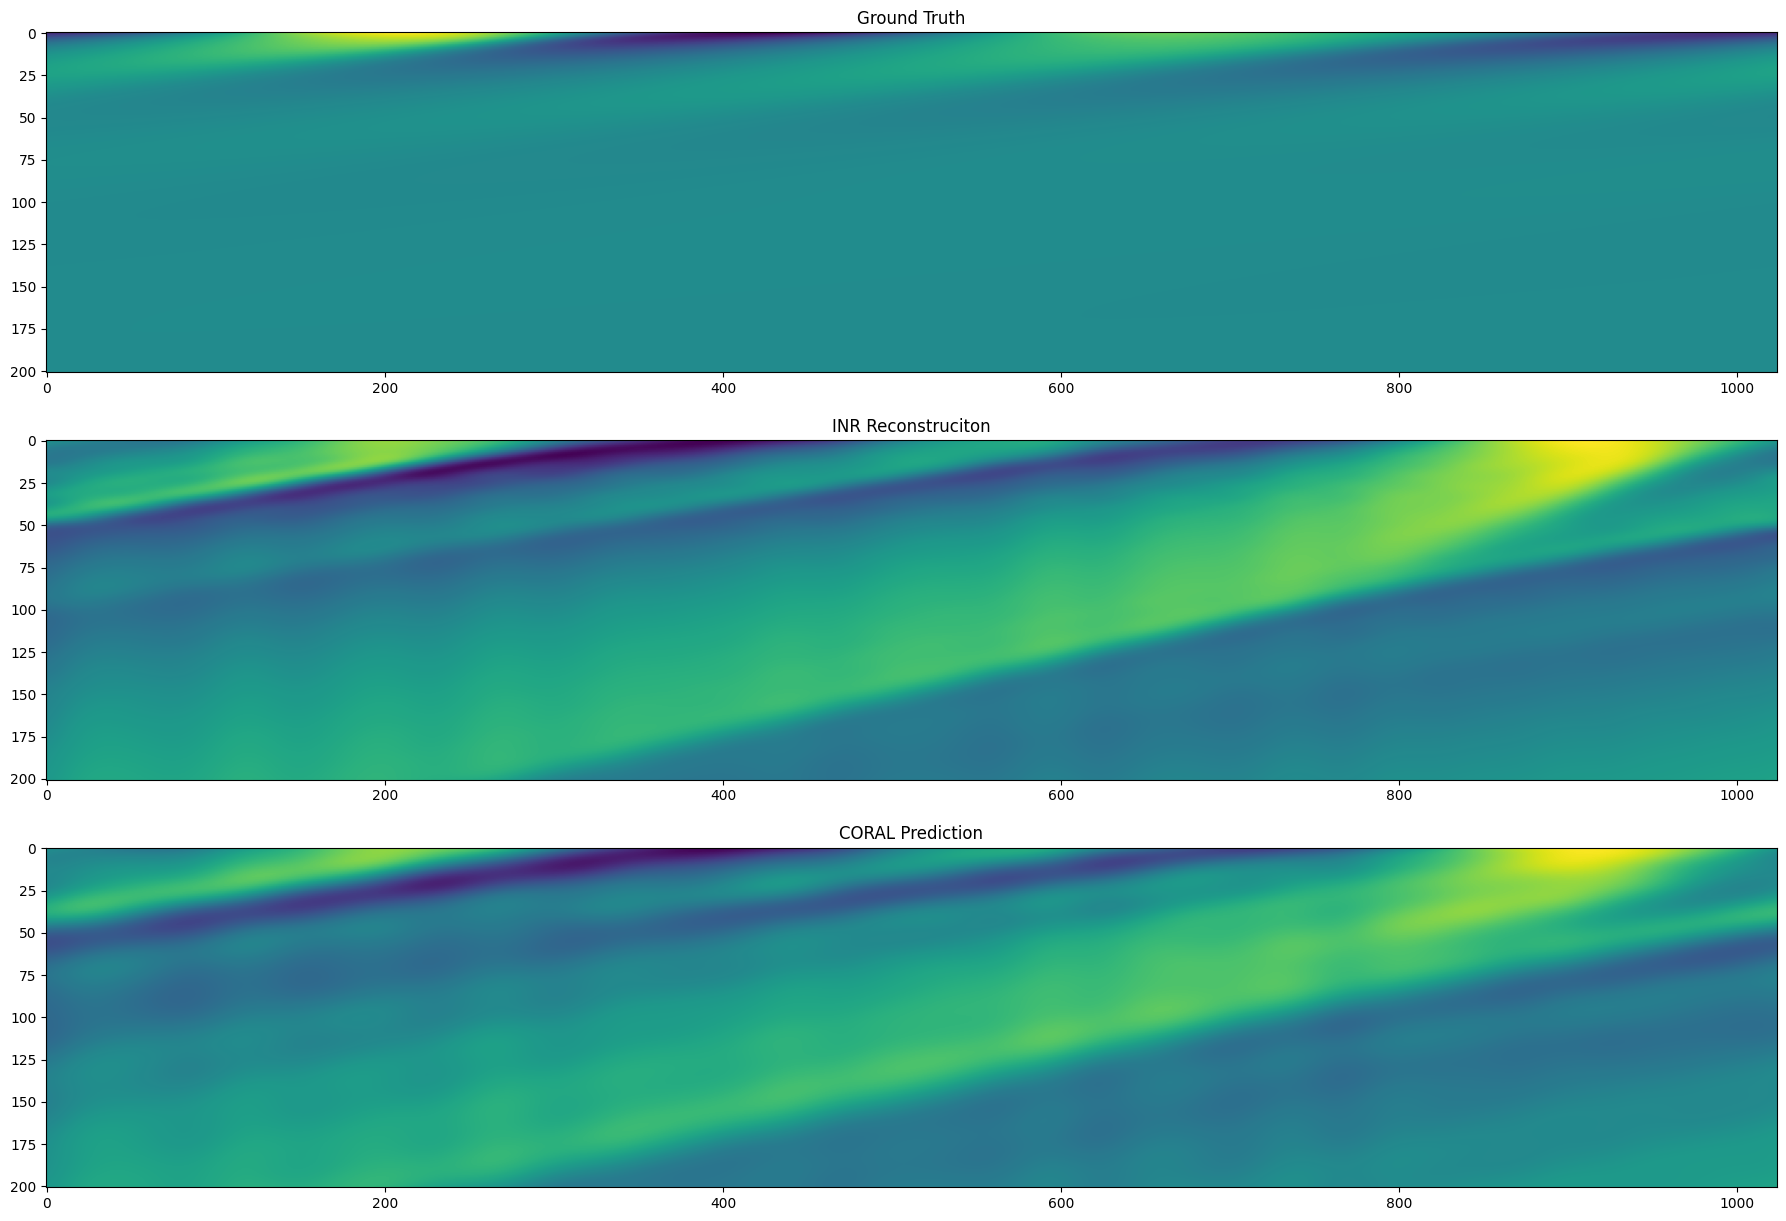

In [14]:
import matplotlib.pyplot as plt


showidx = 1


ode_pred = ode_pred.reshape(-1, T, X) 
inr_pred = inr_pred.reshape(-1, T, X) 
image_ori = graph[showidx].feat.reshape(T, X).cpu()

fig, axes = plt.subplots(3, 1, figsize=(30, 15))

# Set the overall title for the figure
# fig.suptitle("Superresolution")

axes[0].imshow(image_ori)
axes[0].set_title("Ground Truth")

axes[1].imshow(inr_pred[showidx])
axes[1].set_title("INR Reconstruciton")

axes[2].imshow(ode_pred[showidx])
axes[2].set_title("CORAL Prediction")


# plt.figure(figsize=(30, 10))
# plt.imshow(image_ori)
# plt.figure(figsize=(30, 10))
# plt.imshow(inr_pred[showidx])
# plt.figure(figsize=(30, 10))
# plt.imshow(ode_pred[showidx])

In [9]:
p_list = (0.001, 0.002, 0.004, 0.01, 0.02, 0.04, 0.1)
testnum=2
true_list = []
pred_list = []
for i, p in enumerate(p_list):
    test_p_list = (p, )
    testdict = create_dict(test_p_list, trainnum+valnum, testnum)
    testset = GraphBurgers(
        datapath_dict=testdict,
        latent_dim=128,
        missing_rate=0.,
        space_factor=test_space_factor,
        time_factor=test_time_factor, 
        p_transform=p_transform,
    )
    device = torch.device('cpu')
    alpha = alpha.to(device)
    model.to(device)
    inr.to(device)
    load_graph_modulations(
        testset,
        inr,
        device=device,
        inner_steps=inner_steps,
        alpha=alpha,
        batch_size=testnum,
    )
    test_loader = DataLoader(
        testset,
        batch_size=testnum,
        shuffle=False,
        collate_fn=collate_graph_inr,
        num_workers=1,
    )
    graph = next(iter(test_loader))
    modulations = graph.latent_vector
    modulations = modulation_fix(modulations, testnum, T_test, latent_dim, z_transform, device=device)
    modulations = modulations.to(device)
    graph = graph.to(device)
    z_pred = ode_pred_z(model, graph, modulations, timestamps_test, 0, parameterized)
    pred_list.append(z_pred)
    true_list.append(modulations)

# plt.plot(p_list, true_list, 'o-')
# plt.ylabel('Latent Space Distance at Consecutive Time Steps')
# plt.xlabel('parameters')
# print(torch.norm(start))

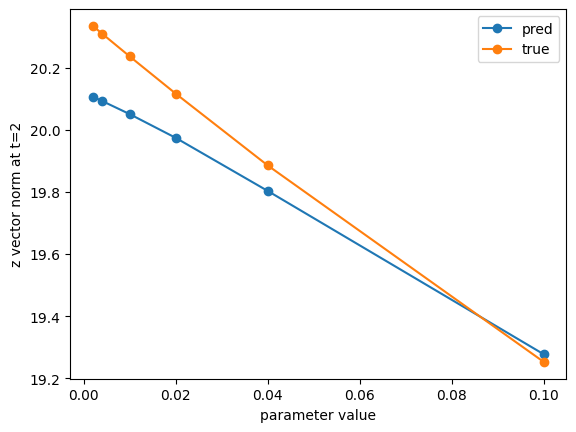

In [12]:
idx=1
tidx =2
pred_1 = []
true_1 = []
for i in range(1, 7):
    pred_1.append(torch.norm(pred_list[i][idx][:, tidx] ).detach().numpy())
    true_1.append(torch.norm(true_list[i][idx][:, tidx]).detach().numpy())
plt.plot(p_list[1:], pred_1, 'o-', label='pred')
plt.plot(p_list[1:], true_1, 'o-', label='true')
plt.xlabel('parameter value')
plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()


In [23]:
len(pred_list[0])

2

In [26]:
batch_size

20

In [29]:
pred_t[1]

array([5.0193553 , 2.709744  , 0.6991549 , 2.5040557 , 0.895856  ,
       1.9373335 , 1.6950253 , 1.3133973 , 1.1179638 , 2.4667873 ,
       3.355335  , 1.3145714 , 0.5284819 , 1.3464835 , 3.7312875 ,
       5.6292815 , 0.96308404, 0.39685765, 0.47741005, 3.0949805 ,
       1.1991954 , 1.5352966 , 0.86613566, 3.2012355 , 2.6299858 ,
       1.0648719 , 1.3701767 , 1.7301937 , 0.7850204 , 0.43755096,
       0.83815444, 3.712051  , 1.0223166 , 8.848246  , 0.91633886,
       2.4394286 , 1.962287  , 0.9711667 , 2.7050984 , 1.2816741 ,
       2.7052696 , 3.4181728 , 1.6555419 , 0.52761257, 4.3278866 ,
       1.6357278 , 3.211708  , 1.3601213 , 5.150215  , 1.1867833 ,
       1.5393152 , 2.8893297 , 0.4155941 , 0.7700022 , 3.3310864 ,
       0.41443712, 2.216179  , 1.5566375 , 2.5666678 , 2.5500135 ,
       1.0035452 , 0.86154604, 1.616029  , 3.2135892 , 1.0269322 ,
       3.2976365 , 1.9718251 , 1.1060067 , 0.3724461 , 1.4553298 ,
       1.8840007 , 1.3522689 , 0.6748426 , 1.4213481 , 2.64770

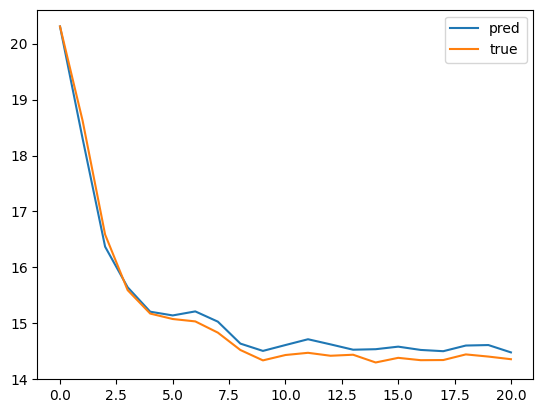

In [43]:
pred_t = []
true_t = []
for t in range(0, T):
    pred_t.append(torch.norm(pred_list[1][idx][:, t] ).detach().numpy())
    true_t.append(torch.norm(true_list[1][idx][:, t] ).detach().numpy())
plt.plot(pred_t, label='pred')
plt.plot(true_t, label='true')
# plt.xlabel('parameter value')
# plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()

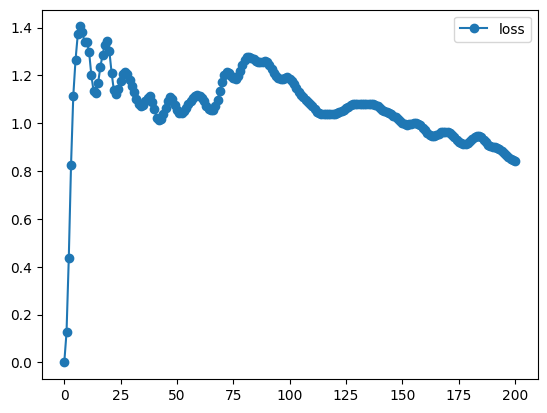

In [13]:
pred_t = [0]*T
true_t = [0]*T
for t in range(0, T):
    for pid in range(0, len(p_list)):
        for idx in range(2):
            pred_t[t] += ((pred_list[pid][idx][:, t] - true_list[pid][idx][:, t])**2).detach().numpy().mean()
            # pred_t.append(torch.norm(pred_list[1][idx][:, t] ).detach().numpy())
            # true_t.append(torch.norm(true_list[1][idx][:, t] ).detach().numpy())
plt.plot(pred_t, '-o', label='loss',)
# plt.plot(true_t, label='true')
# plt.xlabel('parameter value')
# plt.ylabel(f'z vector norm at t={tidx}')
plt.legend()